# Working with JuPedSim Web-UI Scenarios in Python

Load scenario JSON files exported from the web UI and run them programmatically.

**Workflow:**
1. Design your scenario in the web UI (geometry, exits, distributions, etc.)
2. Export the scenario as ZIP
3. Load it here, inspect/modify, run, and analyze

In [1]:
import logging
from datetime import datetime

# Silence jupedsim-scenarios' INFO/DEBUG output. See the howto
# "How do I inspect a scenario?" for the full list of levels.
logging.getLogger("jupedsim_scenarios").setLevel(logging.WARNING)

print(f"Executed on {datetime.now().strftime('%d.%m.%Y, %H:%M')}")

from jupedsim_scenarios import load_scenario, run_scenario, run_sweep

Executed on 25.05.2026, 14:14


## 1. Load and inspect a scenario

In [2]:
scenario = load_scenario("scenario_files/template-scenario.zip")
print(scenario.summary())

Scenario: /Users/chraibi/workspace/PedestrianDynamics/jupedsim-scenarios/examples/cookbook/scenario_files/template-scenario.zip
  Model:         CollisionFreeSpeedModel
  Seed:          420
  Max time:      300s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      0
  Agents:        ~20
    jps-distributions_0: 20 agents


## 2. Modify parameters before running

In [3]:
scenario.set_agent_count(0, 20)
scenario.max_simulation_time = 60
print(scenario.summary())


Scenario: /Users/chraibi/workspace/PedestrianDynamics/jupedsim-scenarios/examples/cookbook/scenario_files/template-scenario.zip
  Model:         CollisionFreeSpeedModel
  Seed:          420
  Max time:      60s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      0
  Agents:        ~20
    jps-distributions_0: 20 agents


## 3. Run the simulation

In [4]:
result = run_scenario(scenario)

print(f"Success:          {result.success}")
print(f"Evacuation time:  {result.evacuation_time:.2f}s")
print(f"Total agents:     {result.total_agents}")
print(f"Evacuated:        {result.agents_evacuated}")
print(f"Remaining:        {result.agents_remaining}")

Success:          True
Evacuation time:  31.54s
Total agents:     20
Evacuated:        20
Remaining:        0


## 4. Analyze trajectory data

In [5]:
df = result.trajectory_dataframe()
print(f"Trajectory: {len(df)} rows, {df['id'].nunique()} agents, {df['frame'].nunique()} frames")
df.head(10)

Trajectory: 5103 rows, 20 agents, 316 frames


,frame,id,x,y,ori_x,ori_y
0,0,1,-14.300273,-0.496209,0.0,0.0
1,0,2,-14.392734,-3.765182,0.0,0.0
2,0,3,-13.250484,1.182421,0.0,0.0
3,0,4,-14.230214,-4.158393,0.0,0.0
4,0,5,-13.709934,0.887278,0.0,0.0
5,0,6,-14.449449,-2.563665,0.0,0.0
6,0,7,-13.428694,-4.395289,0.0,0.0
7,0,8,-13.441598,3.403408,0.0,0.0
8,0,9,-13.422521,-2.653949,0.0,0.0
9,0,10,-13.455260,-0.606839,0.0,0.0


## 5. Plot trajectories

Text(0.5, 1.0, 'Agent trajectories')

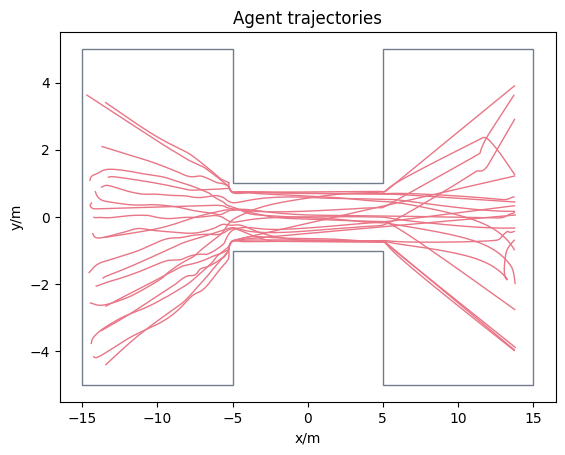

In [6]:
import pedpy

traj = pedpy.TrajectoryData(df, frame_rate=result.frame_rate)
walkable_area = pedpy.WalkableArea(scenario.walkable_polygon)

pedpy.plot_trajectories(
    walkable_area=walkable_area,
    traj=traj,
).set_title("Agent trajectories")

## 6. Parameter sweep — compare seeds

In [7]:
# Seed-only sweep — run_sweep handles per-trial .copy()/.cleanup()
# bookkeeping and dispatches the trials in parallel.
seeds = [1, 2, 3, 4, 5]
sweep = run_sweep(scenario, seeds=seeds, workers=4)
evac_times = sweep.to_dataframe()["evacuation_time"].tolist()
sweep.cleanup()

for s, t in zip(seeds, evac_times, strict=False):
    print(f"  Seed {s}: {t:.2f}s")

print(f"\nMean: {sum(evac_times)/len(evac_times):.2f}s, "
      f"Min: {min(evac_times):.2f}s, Max: {max(evac_times):.2f}s")

  Seed 1: 31.64s
  Seed 2: 30.29s
  Seed 3: 30.29s
  Seed 4: 29.52s
  Seed 5: 30.28s

Mean: 30.40s, Min: 29.52s, Max: 31.64s


## 7. Parameter sweep — compare agent counts

In [8]:
import matplotlib.pyplot as plt

base_scenario = load_scenario("scenario_files/template-scenario.zip")
counts = [5, 10, 20, 30]

# Sweep the agent-count axis via run_sweep — parallel trials, no
# manual .copy() / .cleanup() bookkeeping.
sweep = run_sweep(
    base_scenario,
    axes={"n": counts},
    apply={"n": lambda s, v: s.set_agent_count(0, v)},
    workers=4,
)
df = sweep.to_dataframe()
sweep.cleanup()

results_by_count = dict(zip(df["n"], df["evacuation_time"], strict=False))
for n, t in results_by_count.items():
    print(f"{n} agents: {t:.2f}s")

times = [results_by_count[n] for n in counts]

5 agents: 24.25s
10 agents: 26.69s
20 agents: 31.54s
30 agents: 33.97s


## 8. Plot results

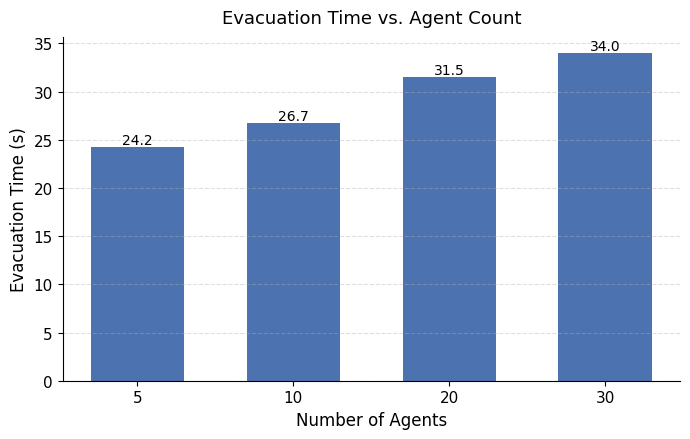

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    [str(n) for n in counts],
    times,
    color="#4C72B0",
    width=0.6
)

ax.set_xlabel("Number of Agents", fontsize=12)
ax.set_ylabel("Evacuation Time (s)", fontsize=12)
ax.set_title("Evacuation Time vs. Agent Count", fontsize=13, pad=10)

ax.tick_params(axis="both", labelsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.4)

# cleaner axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Cleanup

In [10]:
result.cleanup()
print("Done.")

Done.
